In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

In [3]:
df_benign = pd.read_parquet('data/Benign-Monday-no-metadata.parquet')
df_ddos = pd.read_parquet('data/DDoS-Friday-no-metadata.parquet')

df = pd.concat([df_benign, df_ddos], ignore_index=True)

print(f"Data loaded successfully with shape: {df.shape}")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

Data loaded successfully with shape: (680095, 78)


In [ ]:
df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Shape after cleaning: {df.shape}")

print(df['Label'].value_counts())

Shape after cleaning: (680095, 78)
Label
Benign    552081
DDoS      128014
Name: count, dtype: int64


In [ ]:
X = df.drop('Label', axis=1)
y = df['Label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data engineered and ready for training.")

Data engineered and ready for training.


In [6]:
print("Training the Random Forest Security Tool...")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
print("Model training complete.")

Training the Random Forest Security Tool...
Model training complete.


Overall Accuracy: 99.98%

Classification Report (Focus on Recall for Attack Classes):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    165626
        DDoS       1.00      1.00      1.00     38403

    accuracy                           1.00    204029
   macro avg       1.00      1.00      1.00    204029
weighted avg       1.00      1.00      1.00    204029



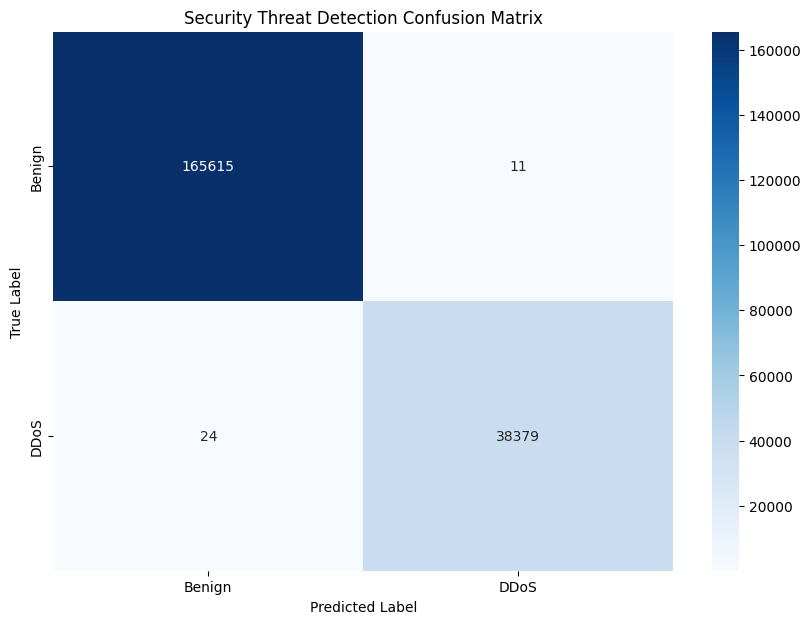

['label_encoder.pkl']

In [7]:
y_pred = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report (Focus on Recall for Attack Classes):")

target_names = label_encoder.inverse_transform(np.unique(y_test))
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Security Threat Detection Confusion Matrix')
plt.show()

joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')